<a href="https://colab.research.google.com/github/philip-1520/Reconhecimento-de-0-e-1-por-Rede-Hopfield/blob/main/Reconhecimento_de_0_e_1_por_Rede_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
# Manipular dados
import pandas as pd
import numpy as np

# Selecionar valores aleatoriamente
from random import randint, sample

# Calcular distribuição binomial
from math import comb

# Armazenar métricas
from collections import Counter

# Plotar métricas
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [82]:
# Instancia e separa os dados de zeros e uns

data = pd.read_json('algarismos_binarios.json')

zeros = data[0]
zeros_size = len(zeros)

ones = data[1]
ones_size = len(ones)

In [83]:
# Mostra de forma legível os dígitos armazenados

def printed_digit(digit: list) -> list:
    digit_vector = np.ravel(np.array(digit))
    image = np.where(digit_vector == 1, '■', ' ')
    return image.reshape(7, 5)

print(f"""
ZERO""")

for zero in zeros:
    print(f"""
{printed_digit(zero)}""")

print("""
ONE""")

for one in ones:
    print(f"""
{printed_digit(one)}""")


ZERO

[[' ' ' ' ' ' ' ' ' ']
 [' ' ' ' '■' ' ' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' ' ' '■' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ']]

[[' ' ' ' ' ' ' ' ' ']
 [' ' '■' '■' '■' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' '■' '■' '■' ' ']
 [' ' ' ' ' ' ' ' ' ']]

[[' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ']
 [' ' '■' '■' '■' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' '■' '■' '■' ' ']
 [' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ']]

[[' ' ' ' ' ' ' ' ' ']
 [' ' ' ' '■' ' ' ' ']
 [' ' '■' '■' '■' ' ']
 [' ' '■' ' ' '■' ' ']
 [' ' '■' '■' '■' ' ']
 [' ' ' ' '■' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ']]

[[' ' ' ' '■' ' ' ' ']
 [' ' '■' '■' '■' ' ']
 ['■' '■' ' ' '■' '■']
 ['■' '■' ' ' '■' '■']
 ['■' '■' ' ' '■' '■']
 [' ' '■' '■' '■' ' ']
 [' ' ' ' '■' ' ' ' ']]

[['■' '■' '■' '■' '■']
 ['■' '■' '■' '■' '■']
 ['■' '■' ' ' '■' '■']
 ['■' '■' ' ' '■' '■']
 ['■' '■' ' ' '■' '■']
 ['■' '■' '■' '■' '■']
 ['■' '■' '■' '■' '■']]

[[' ' ' ' ' ' '

In [84]:
# Converte os dígitos de exemplo de binário (0, 1) para bipolar (-1, 1)

def to_bipolar(matrices: np.ndarray) -> np.ndarray:
    return np.array([2*matrix - 1 for matrix in matrices])

zeros = zeros.apply(lambda x: to_bipolar(np.ravel(np.array(x))))
ones = ones.apply(lambda x: to_bipolar(np.ravel(np.array(x))))

In [85]:
def generate_model(zeros, ones):

    # Separa uma imagem de treino para cada dígito e as outras como teste
    random_zero = randint(0, zeros_size-1)
    random_one = randint(0, ones_size-1)

    train_zeros = zeros[random_zero]
    test_zeros = zeros.drop(random_zero)
    train_ones = ones[random_one]
    test_ones = ones.drop(random_one)

    # Gera a matriz de pesos
    W_zeros = np.outer(train_zeros.T, train_zeros)
    W_ones = np.outer(train_ones.T, train_ones)
    W = (W_zeros + W_ones)
    np.fill_diagonal(W, 0)

    return W, test_zeros, test_ones

In [86]:
# Analisa os valores de teste
def testing(W, test_set, labels):

    # Gera um dicionário para guardar informações do teste
    result = {
        'correct': 0, # Mede quando a rede estabiliza no dígito certo
        'bipolar_correct': 0, # Mede quando a rede estabiliza no dígito certo ou no padrão inverso igualmente estável
        'tests': 0 # Mede a quantidade de testes
    }

    # Analise cada imagem no conjunto de teste
    for entry in test_set:

        # O "step" é o estado atual da rede, que inicialmente não está convergida
        step = entry.copy()
        converged = False

        # Enquanto a rede não converge, o estado é atualizado
        while not converged:

            previous_step = step.copy()

            # Os neurônios são assincronamente atualizados em uma ordem aleatória
            for i in np.random.permutation(len(step)):

                h = W[i] @ step
                if h >= 0:
                    step[i] = 1
                elif h < 0:
                    step[i] = -1

            # Se nenhum neurônio atualizar, então a rede convergiu
            if np.array_equal(step, previous_step):
                converged = True
                output = step.copy()

        result['tests'] += 1
        if any(np.array_equal(output, target) for target in labels):
            result['correct'] += 1
            result['bipolar_correct'] += 1
        elif any(np.array_equal(-1*output, target) for target in labels):
            result['bipolar_correct'] += 1

    return result

In [87]:
# Define o número de iterações
cycles = 10**3

# Gera um dicionário para guardar métricas de desempenho
metrics = {
    'accuracy': Counter(),
    'recall': Counter(),
    'size': 0
}

for cycle in range(cycles):

    W, test_zeros, test_ones = generate_model(zeros, ones)
    result_zeros = testing(W, test_zeros, zeros)
    result_ones = testing(W, test_ones, ones)

    correct = result_zeros['correct'] + result_ones['correct']
    bipolar_correct = result_zeros['bipolar_correct'] + result_ones['bipolar_correct']
    size = result_zeros['tests'] + result_ones['tests']

    metrics['accuracy'][correct] += 1
    metrics['recall'][bipolar_correct] += 1
    metrics['size'] += size

print(metrics)

{'accuracy': Counter({13: 235, 12: 175, 11: 139, 10: 94, 14: 90, 8: 68, 9: 55, 6: 34, 7: 34, 15: 25, 5: 24, 4: 10, 16: 8, 3: 7, 2: 2}), 'recall': Counter({13: 213, 14: 185, 12: 162, 11: 131, 10: 70, 15: 60, 9: 56, 8: 46, 7: 40, 16: 14, 6: 9, 5: 8, 4: 3, 3: 2, 17: 1}), 'size': 18000}


In [88]:
# Cria dataframes com os dados para facilitar a plotagem

accuracy = pd.DataFrame(sorted(metrics['accuracy'].items()), columns=['values', 'accuracy'])
recall = pd.DataFrame(sorted(metrics['recall'].items()), columns=['values', 'recall'])
size = metrics['size']

conclusion = pd.merge(accuracy, recall, how='outer', on='values')
conclusion = conclusion.fillna(0)

conclusion['% accuracy'] = conclusion['accuracy']/sum(conclusion['accuracy'])
conclusion['% accuracy cum'] = conclusion['% accuracy'][::-1].cumsum()[::-1]

print(conclusion)

    values  accuracy  recall  % accuracy  % accuracy cum
0        2       2.0     0.0       0.002           1.000
1        3       7.0     2.0       0.007           0.998
2        4      10.0     3.0       0.010           0.991
3        5      24.0     8.0       0.024           0.981
4        6      34.0     9.0       0.034           0.957
5        7      34.0    40.0       0.034           0.923
6        8      68.0    46.0       0.068           0.889
7        9      55.0    56.0       0.055           0.821
8       10      94.0    70.0       0.094           0.766
9       11     139.0   131.0       0.139           0.672
10      12     175.0   162.0       0.175           0.533
11      13     235.0   213.0       0.235           0.358
12      14      90.0   185.0       0.090           0.123
13      15      25.0    60.0       0.025           0.033
14      16       8.0    14.0       0.008           0.008
15      17       0.0     1.0       0.000           0.000


In [89]:
# Retorna a probabilidade de ao menos x ocorrências de min(num) ao max(num)
def random_guessing(total: int, num: np.ndarray) -> np.ndarray:

        # Array para armazenar todas as probabilidades do problema
        probability = np.zeros(total + 1)

        # Probabilidade de acertar todos os exemplos
        probability[-1] = 1/(2**total)

        # Probabilidade de acertar i exemplos
        for i in range(total-1, -1, -1):
            probability[i] = probability[i+1] + comb(total, i)/(2**total)
        return probability[min(num): max(num)+1]

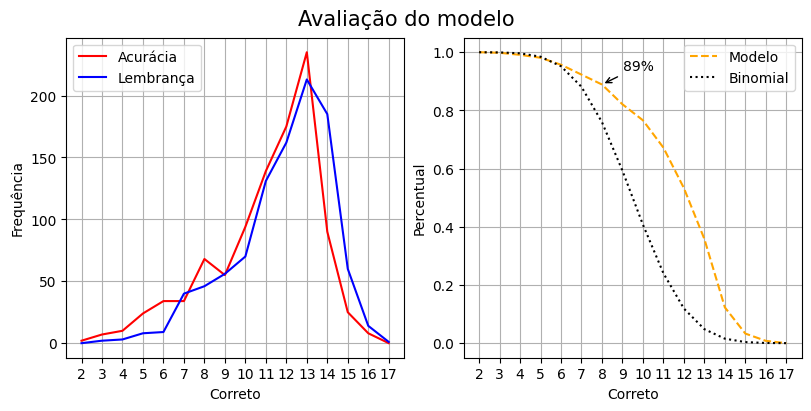

In [91]:
fig = plt.figure(figsize=(8, 4), constrained_layout=True)
fig.suptitle('Avaliação do modelo', fontsize=15)
gs = fig.add_gridspec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(conclusion['values'], conclusion['accuracy'], label='Acurácia', color='red')
ax1.plot(conclusion['values'], conclusion['recall'], label='Lembrança', color='blue')
ax1.set_ylabel('Frequência')
ax1.set_xlabel('Correto')
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.grid()
ax1.legend()

num_test = len(test_zeros) + len(test_ones)
baseline_c = round(conclusion['values'].iloc[-1]/2)
baseline_cum_percentual = conclusion['% accuracy cum'].loc[conclusion['values'] == baseline_c].iloc[0]

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(conclusion['values'], conclusion['% accuracy cum'], label='Modelo', color='orange', linestyle='--')
ax2.plot(conclusion['values'], random_guessing(num_test, conclusion['values']), label='Binomial', color='black', linestyle=':')
ax2.annotate(f'{baseline_cum_percentual*100:.0f}%',
             xy=(baseline_c, baseline_cum_percentual),
             xytext=(15, 10),
             textcoords='offset points',
             arrowprops={
                 'color':'black',
                 'arrowstyle': '->'}
             )
ax2.set_ylabel('Percentual')
ax2.set_xlabel('Correto')
ax2.xaxis.set_major_locator(MultipleLocator(1))
ax2.grid()
ax2.legend()

plt.show()